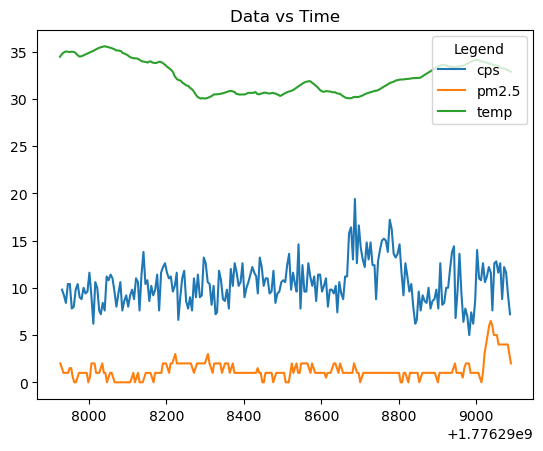

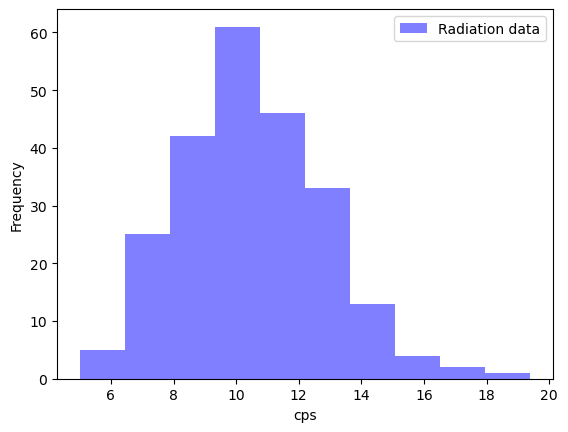

mean: 10.49655172413793 std: 2.268013263147991


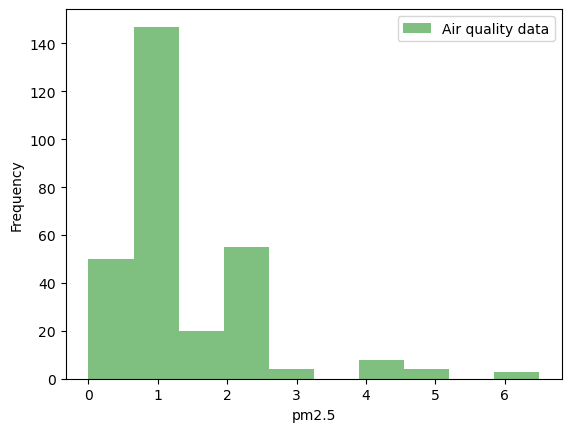

mean: 1.302405498281787 std: 1.0261886567011353


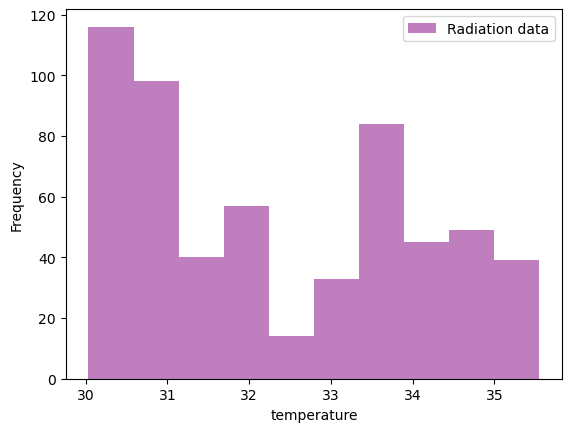

mean: 32.34620448369565 std: 1.710521409235924


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rad_data = pd.read_csv('data/radiation.csv')
airqual_data = pd.read_csv('data/air_quality.csv')
pth_data = pd.read_csv('data/pth.csv')

plt.plot(rad_data['timestamp'], rad_data['cps'])
plt.plot(airqual_data['timestamp'], airqual_data['pm25_mean'])
plt.plot(pth_data['timestamp'], pth_data['temp_mean'])

plt.title('Data vs Time')
plt.legend(loc='upper right', title="Legend", labels=['cps', 'pm2.5', 'temp'])
plt.show()

#radiation data
plt.hist(rad_data['cps'], bins = 10, label = 'Radiation data', color='blue', alpha = 0.5)
plt.ylabel('Frequency')
plt.xlabel('cps')
plt.legend(loc = 'upper right')
plt.show()

rad_mean = rad_data['cps'].mean()
rad_std = rad_data['cps'].std()
print(f'mean: {rad_mean} std: {rad_std}')

#air quality data
plt.hist(airqual_data['pm25_mean'], bins = 10, label = 'Air quality data', color='green', alpha = 0.5)
plt.ylabel('Frequency')
plt.xlabel('pm2.5')
plt.legend(loc = 'upper right')
plt.show()

airqual_mean = airqual_data['pm25_mean'].mean()
airqual_std = airqual_data['pm25_mean'].std()
print(f'mean: {airqual_mean} std: {airqual_std}')

#temperature data
plt.hist(pth_data['temp_mean'], bins = 10, label = 'Radiation data', color='purple', alpha = 0.5)
plt.ylabel('Frequency')
plt.xlabel('temperature')
plt.legend(loc = 'upper right')
plt.show()

temp_mean = pth_data['temp_mean'].mean()
temp_std = pth_data['temp_mean'].std()
print(f'mean: {temp_mean} std: {temp_std}')



The radiation counts per second data seems to be about normal as it is approximately symmetric and unimodal, resembling a bell curve. 
The Air quality data is dramatically skewed to the right making it not normal
The temperature data is bimodal which makes it also not follow the bell shape of a normal distribution. 
The Air quality data may not follow a normal distribution because normally, the values are very low. This means any small change can create a large temporary spike, like someone kicking up dust while walking. The temperature can dramatically change in shaded areas, or different surroundings (ex walking near creek vs concrete buildings)

Because sigma = sqrt(N), then N = sigma^2, which means the expected variance should be 10.4965 (mean calculated before), but the measured variance is        2.2680^2 = 5.1438. The measured variance is significanly lower than expected mean which is often caused by detector dead time. This happens when the counter takes a fraction of a millisecond to process a count and will miss other decay events.

In [11]:
N = len(rad_data['cps'])

measured_var = rad_std**2
expected_var = rad_mean

uncert_std = rad_std / np.sqrt(2 * N)
uncert_var = 2 * rad_std * uncert_std

lower_bound = measured_var - (2 * uncert_var)
upper_bound = measured_var + (2 * uncert_var)

if lower_bound <= expected_var <= upper_bound:
    print("The expected variance is within confidence interval. They agree.")
else:
    print("The expected variance is outside confidence interval. They do not agree.")

The expected variance is outside confidence interval. They do not agree.


The data actually showed significantly less variation than expected from pure Poisson statistics, yielding a measured variance of ~5.14 compared to an expected variance of ~10.50. This restricted spread is usually caused by detector dead time, where the detector doesn't record rapid, successive decay events, artificially smoothing the data. If excess variation had been present, it would typically point to external inconsistencies rather than pure statistical randomness, such as a moving radiation source, a fluctuating background environment, or electronic noise in the detector.